# Looking at Bell Field

This is code for looking at the data we've collected across all of Bell Field. It loads in all of the continuous and manual data for each piezometer and each creek monitoring station. It explains the code less thoroughly than the script meant for one monitoring station.

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.dates as mdates

The code chunk below installs the package that runs a hampel filter--this is what cleans the spikes out of the data caused by removing the hobo sensors from the wells. After running it once, the package is installed in your environment, and you should comment out the cell to keep your cache clear.

In [26]:
# pip install hampel

In [27]:
import pandas as pd
from hampel import hampel #this allows the hampel package to run

In [28]:
import os # Allows python to communicate directly with the computer's operating system

### Reading in all the Hobo Data

In [254]:
# P1
P1hobodf = pd.read_csv('P1_current.csv')
P1hobodf = P1hobodf.dropna()

P1hobodf['Date-Time'] = pd.to_datetime(P1hobodf['Date-Time']) 
P1hobodf.index = pd.DatetimeIndex(P1hobodf['Date-Time']) 

In [255]:
# P2
P2hobodf = pd.read_csv('P2_current.csv')
P2hobodf = P2hobodf.dropna()

P2hobodf['Date-Time'] = pd.to_datetime(P2hobodf['Date-Time']) 
P2hobodf.index = pd.DatetimeIndex(P2hobodf['Date-Time']) 

In [256]:
# P3
P3hobodf = pd.read_csv('P3_current.csv')
P3hobodf = P3hobodf.dropna()

P3hobodf['Date-Time'] = pd.to_datetime(P3hobodf['Date-Time']) 
P3hobodf.index = pd.DatetimeIndex(P3hobodf['Date-Time']) 

In [257]:
# P4
P4hobodf = pd.read_csv('P4_current.csv')
P4hobodf = P4hobodf.dropna()

P4hobodf['Date-Time'] = pd.to_datetime(P4hobodf['Date-Time']) 
P4hobodf.index = pd.DatetimeIndex(P4hobodf['Date-Time']) 

In [258]:
# P5
P5hobodf = pd.read_csv('P5_current.csv')
P5hobodf = P5hobodf.dropna()

P5hobodf['Date-Time'] = pd.to_datetime(P5hobodf['Date-Time']) 
P5hobodf.index = pd.DatetimeIndex(P5hobodf['Date-Time']) 

In [259]:
# C1
C1hobodf = pd.read_csv('P1_creek_current.csv')
C1hobodf = C1hobodf.dropna()

C1hobodf['Date-Time'] = pd.to_datetime(C1hobodf['Date-Time']) 
C1hobodf.index = pd.DatetimeIndex(C1hobodf['Date-Time']) 

In [260]:
# Downstream (near P1)
downst = pd.read_csv('Dwnstrm_current.csv')
downst = downst.dropna()

downst['Date-Time'] = pd.to_datetime(downst['Date-Time']) 
downst.index = pd.DatetimeIndex(downst['Date-Time']) 

In [261]:
# C2
C2hobodf = pd.read_csv('P2_creek_current.csv')
C2hobodf = C2hobodf.dropna()

C2hobodf['Date-Time'] = pd.to_datetime(C2hobodf['Date-Time']) 
C2hobodf.index = pd.DatetimeIndex(C2hobodf['Date-Time']) 

In [262]:
# Midstream (near P3)
midst = pd.read_csv('Mdstrm_current.csv')
midst = midst.dropna()

midst['Date-Time'] = pd.to_datetime(midst['Date-Time']) 
midst.index = pd.DatetimeIndex(midst['Date-Time']) 

In [263]:
# Spring (just upstream of P3)
spring = pd.read_csv('Spring_current.csv')
spring = spring.dropna()

spring['Date-Time'] = pd.to_datetime(spring['Date-Time']) 
spring.index = pd.DatetimeIndex(spring['Date-Time']) 

In [264]:
# C4
C4hobodf = pd.read_csv('P4_creek_current.csv')
C4hobodf = C4hobodf.dropna()

C4hobodf['Date-Time'] = pd.to_datetime(C4hobodf['Date-Time']) 
C4hobodf.index = pd.DatetimeIndex(C4hobodf['Date-Time']) 

In [265]:
# C5
C5hobodf = pd.read_csv('P5_creek_cond_current.csv')
C5hobodf = C5hobodf.dropna()

C5hobodf['Date-Time'] = pd.to_datetime(C5hobodf['Date-Time']) 
C5hobodf.index = pd.DatetimeIndex(C5hobodf['Date-Time']) 

### Filtering the data

A hampel filter uses a running average to compute outliers in time-dependent data. Instead of dropping outliers, it replaces them with the local median. Visit https://www.mathworks.com/help/signal/ref/hampel.html for more information.

In [266]:
# P1
P1filtered = hampel(P1hobodf['Temperature'], window_size=6, n_sigma=1.5)
P1filtered = pd.DataFrame(P1filtered.filtered_data.to_numpy(), index=P1hobodf.index)
P1hobodf['FilteredTemp'] = P1filtered
P1filteredSPC = hampel(P1hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P1filteredSPC = pd.DataFrame(P1filteredSPC.filtered_data.to_numpy(), index=P1hobodf.index)
P1hobodf['FilteredSPC'] = P1filteredSPC
P1hobodf = P1hobodf.iloc[1:-1]

In [267]:
# P2
P2filtered = hampel(P2hobodf['Temperature'], window_size=6, n_sigma=1.5)
P2filtered = pd.DataFrame(P2filtered.filtered_data.to_numpy(), index=P2hobodf.index)
P2hobodf['FilteredTemp'] = P2filtered
P2filteredSPC = hampel(P2hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P2filteredSPC = pd.DataFrame(P2filteredSPC.filtered_data.to_numpy(), index=P2hobodf.index)
P2hobodf['FilteredSPC'] = P2filteredSPC
P2hobodf = P2hobodf.iloc[1:-1]

In [268]:
# P3
P3filtered = hampel(P3hobodf['Temperature'], window_size=6, n_sigma=1.5)
P3filtered = pd.DataFrame(P3filtered.filtered_data.to_numpy(), index=P3hobodf.index)
P3hobodf['FilteredTemp'] = P3filtered
P3filteredSPC = hampel(P3hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P3filteredSPC = pd.DataFrame(P3filteredSPC.filtered_data.to_numpy(), index=P3hobodf.index)
P3hobodf['FilteredSPC'] = P3filteredSPC
P3hobodf = P3hobodf.iloc[1:-1]

In [269]:
# P4
P4filtered = hampel(P4hobodf['Temperature'], window_size=6, n_sigma=1.5)
P4filtered = pd.DataFrame(P4filtered.filtered_data.to_numpy(), index=P4hobodf.index)
P4hobodf['FilteredTemp'] = P4filtered
P4filteredSPC = hampel(P4hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P4filteredSPC = pd.DataFrame(P4filteredSPC.filtered_data.to_numpy(), index=P4hobodf.index)
P4hobodf['FilteredSPC'] = P4filteredSPC
P4hobodf = P4hobodf.iloc[1:-1]

In [270]:
# P5
P5filtered = hampel(P5hobodf['Temperature'], window_size=6, n_sigma=1.5)
P5filtered = pd.DataFrame(P5filtered.filtered_data.to_numpy(), index=P5hobodf.index)
P5hobodf['FilteredTemp'] = P5filtered
P5filteredSPC = hampel(P5hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
P5filteredSPC = pd.DataFrame(P5filteredSPC.filtered_data.to_numpy(), index=P5hobodf.index)
P5hobodf['FilteredSPC'] = P5filteredSPC
P5hobodf = P5hobodf.iloc[1:-1]

In [271]:
# Downstream
downstfilt = hampel(downst['Temperature'], window_size=6, n_sigma=1.5)
downstfilt = pd.DataFrame(downstfilt.filtered_data.to_numpy(), index=downst.index)
downst['FilteredTemp'] = downstfilt
downstfiltSPC = hampel(downst['Specific Conductivity'], window_size=6, n_sigma=1.5)
downstfiltSPC = pd.DataFrame(downstfiltSPC.filtered_data.to_numpy(), index=downst.index)
downst['FilteredSPC'] = downstfiltSPC
downst = downst.iloc[1:-1]

In [272]:
# Midstream
midstfilt = hampel(midst['Temperature'], window_size=6, n_sigma=1.5)
midstfilt = pd.DataFrame(midstfilt.filtered_data.to_numpy(), index=midst.index)
midst['FilteredTemp'] = midstfilt
midstfiltSPC = hampel(midst['Specific Conductivity'], window_size=6, n_sigma=1.5)
midstfiltSPC = pd.DataFrame(midstfiltSPC.filtered_data.to_numpy(), index=midst.index)
midst['FilteredSPC'] = midstfiltSPC
midst = midst.iloc[1:-1]

In [273]:
# C5
C5filtered = hampel(C5hobodf['Temperature'], window_size=6, n_sigma=1.5)
C5filtered = pd.DataFrame(C5filtered.filtered_data.to_numpy(), index=C5hobodf.index)
C5hobodf['FilteredTemp'] = C5filtered
C5filteredSPC = hampel(C5hobodf['Specific Conductivity'], window_size=6, n_sigma=1.5)
C5filteredSPC = pd.DataFrame(C5filteredSPC.filtered_data.to_numpy(), index=C5hobodf.index)
C5hobodf['FilteredSPC'] = C5filteredSPC
C5hobodf = C5hobodf.iloc[1:-1]

In [274]:
# Spring
springfilt = hampel(spring['Temperature'], window_size=6, n_sigma=1.5)
springfilt = pd.DataFrame(springfilt.filtered_data.to_numpy(), index=spring.index)
spring['FilteredTemp'] = springfilt
springfiltSPC = hampel(spring['Specific Conductivity'], window_size=6, n_sigma=1.5)
springfiltSPC = pd.DataFrame(springfiltSPC.filtered_data.to_numpy(), index=spring.index)
spring['FilteredSPC'] = springfiltSPC
spring = spring.iloc[1:-1]

In [275]:
# C1
C1filtered = hampel(C1hobodf['Temperature'], window_size=6, n_sigma=1.5)
C1filtered = pd.DataFrame(C1filtered.filtered_data.to_numpy(), index=C1hobodf.index)
C1hobodf['FilteredTemp'] = C1filtered
C1hobodf = C1hobodf.iloc[1:-1]

In [276]:
# C2
C2filtered = hampel(C2hobodf['Temperature'], window_size=6, n_sigma=1.5)
C2filtered = pd.DataFrame(C2filtered.filtered_data.to_numpy(), index=C2hobodf.index)
C2hobodf['FilteredTemp'] = C2filtered
C2hobodf = C2hobodf.iloc[1:-1]

In [277]:
# C4
C4filtered = hampel(C4hobodf['Temperature'], window_size=6, n_sigma=1.5)
C4filtered = pd.DataFrame(C4filtered.filtered_data.to_numpy(), index=C4hobodf.index)
C4hobodf['FilteredTemp'] = C4filtered
C4hobodf = C4hobodf.iloc[1:-1]

### Add in the manual data

In [278]:
P1mandf = pd.read_csv('Well_Sampling_Data_ALL - P1.csv', index_col=False) 
P1mandf['Date'] = pd.to_datetime(P1mandf['Date']) 

In [279]:
P2mandf = pd.read_csv('Well_Sampling_Data_ALL - P2.csv', index_col=False) 
P2mandf['Date'] = pd.to_datetime(P2mandf['Date']) 

In [280]:
P3mandf = pd.read_csv('Well_Sampling_Data_ALL - P3.csv', index_col=False) 
P3mandf['Date'] = pd.to_datetime(P3mandf['Date']) 

In [281]:
P4mandf = pd.read_csv('Well_Sampling_Data_ALL - P4.csv', index_col=False) 
P4mandf['Date'] = pd.to_datetime(P4mandf['Date']) 

In [282]:
P5mandf = pd.read_csv('Well_Sampling_Data_ALL - P5.csv', index_col=False) 
P5mandf['Date'] = pd.to_datetime(P5mandf['Date']) 

In [283]:
C1mandf = pd.read_csv('Well_Sampling_Data_ALL - C1.csv', index_col=False) 
C1mandf['Date'] = pd.to_datetime(C1mandf['Date']) 

In [284]:
C2mandf = pd.read_csv('Well_Sampling_Data_ALL - C2.csv', index_col=False) 
C2mandf['Date'] = pd.to_datetime(C2mandf['Date']) 

In [285]:
C3mandf = pd.read_csv('Well_Sampling_Data_ALL - C3.csv', index_col=False) 
C3mandf['Date'] = pd.to_datetime(C3mandf['Date']) 

In [286]:
C4mandf = pd.read_csv('Well_Sampling_Data_ALL - C4.csv', index_col=False) 
C4mandf['Date'] = pd.to_datetime(C4mandf['Date']) 

In [287]:
C5mandf = pd.read_csv('Well_Sampling_Data_ALL - C5.csv', index_col=False) 
C5mandf['Date'] = pd.to_datetime(C5mandf['Date']) 

In [288]:
springman = pd.read_csv('Well_Sampling_Data_ALL - Spring.csv', index_col=False) 
springman['Date'] = pd.to_datetime(springman['Date']) 

### Add in the other datasets

In [289]:
# Add the NOAA air temp data.
weatherdf = pd.read_csv('NOAAHastingsDamTemp.csv')
weatherdf['Date'] = pd.to_datetime(weatherdf['Date'])

In [290]:
# Add precipitation data:
precip = pd.read_csv('NOAAFaribaultPrecipitation.csv')
precip['Date'] = pd.to_datetime(precip['Date'])
precip = precip[precip['PrecipitationCM'] != 0]

# Plot the data

### Plotting temperatures across the piezometers:

Creating a way to color the piezometers up to downgradient-- Make a discrete sequence of evenly spaced viridis colors. Call them without parentheses in the plot. 

In [291]:
viridis = plt.colormaps['viridis']
one = viridis(0)
two = viridis(0.25)
three = viridis(0.5)
four = viridis(0.75)
five = viridis(1.0)

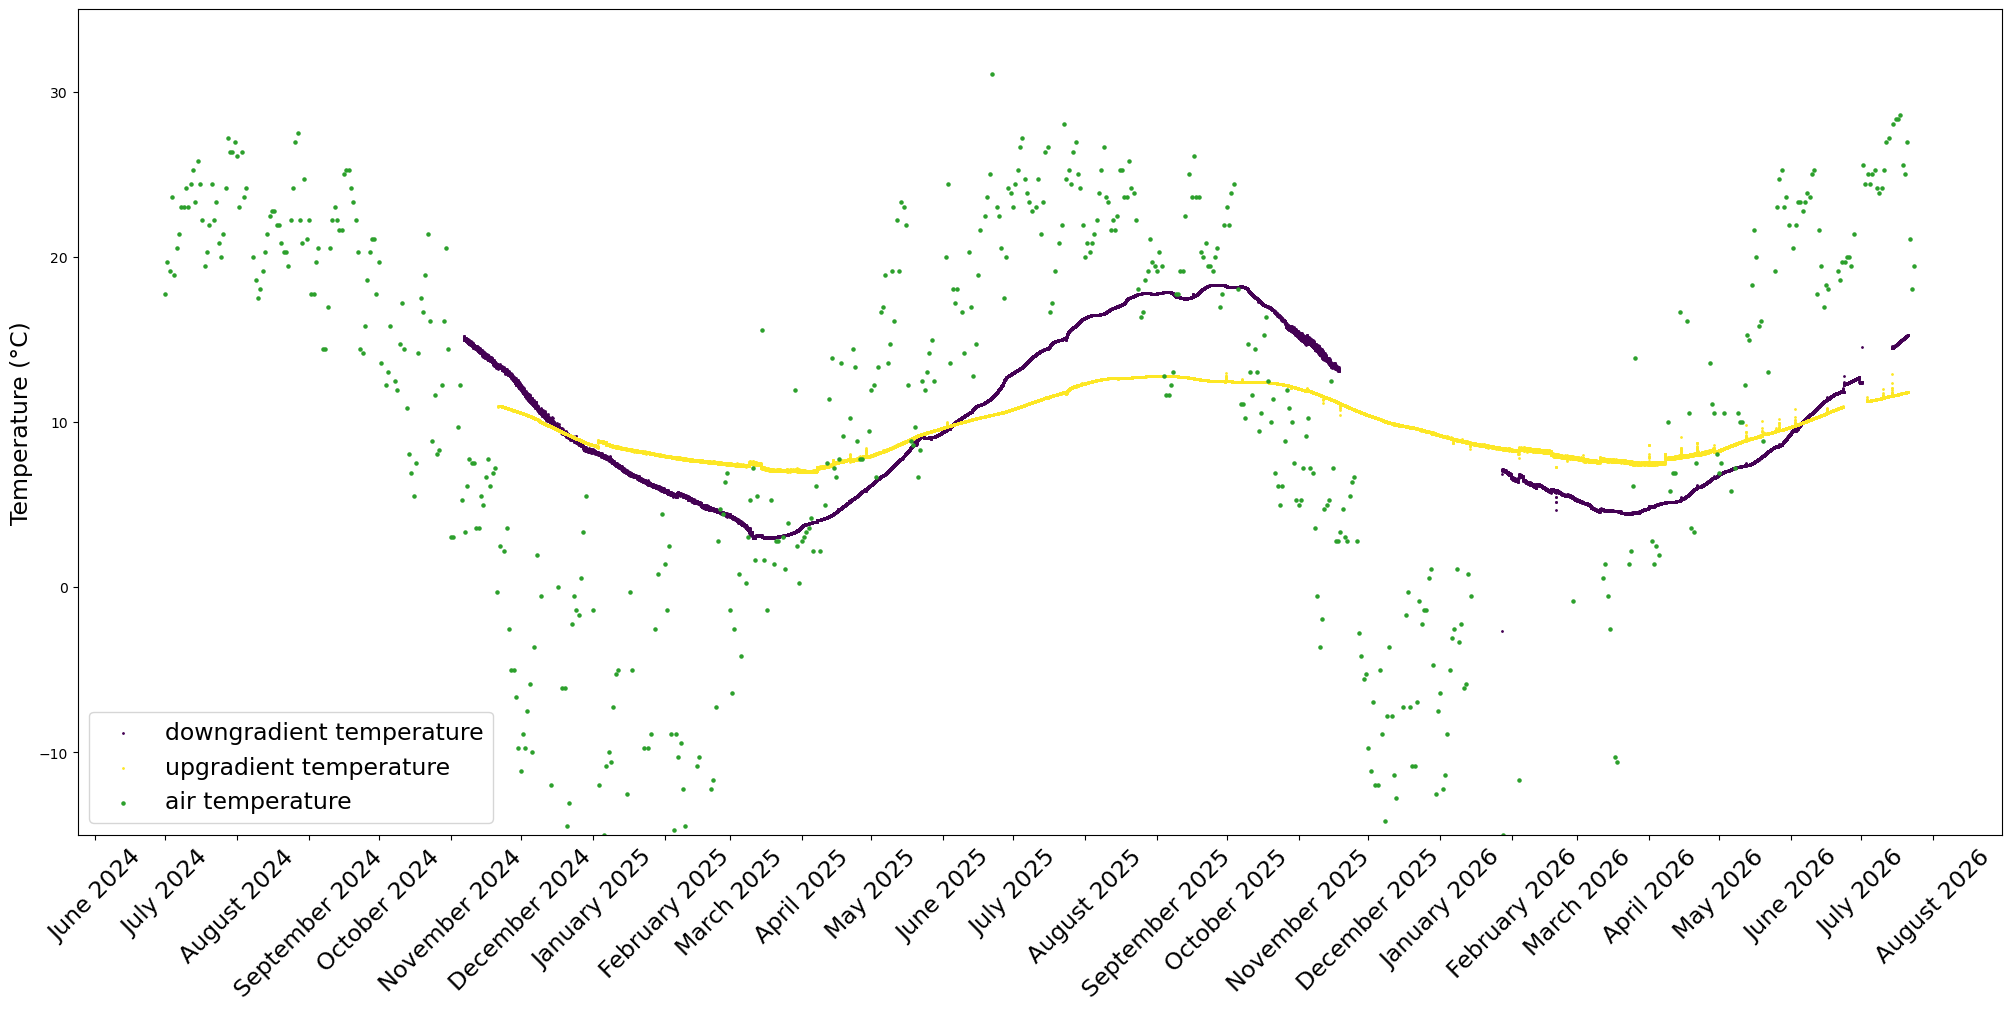

In [326]:

fig, ax = plt.subplots(layout='constrained', figsize=(20, 10))
ax.scatter(P1hobodf.index, P1hobodf.FilteredTemp, s = 1, color = one, label = 'downgradient temperature')
# ax.scatter(P2hobodf.index, P2hobodf.FilteredTemp, s = 1, color = two, label = 'P2 temperature')
# ax.scatter(P3hobodf.index, P3hobodf.FilteredTemp, s = 1, color = three, label = 'P3 temperature')
# ax.scatter(P4hobodf.index, P4hobodf.FilteredTemp, s = 1, color = four, label = 'P4 temperature')
ax.scatter(P5hobodf.index, P5hobodf.FilteredTemp, s = 1, color = five, label = 'upgradient temperature')

ax.scatter(weatherdf.Date, weatherdf.MeanTempC, s = 5, color='tab:green', label = 'air temperature') 

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
plt.xticks(rotation=45, fontsize = 17)

# plt.xlabel('date', fontsize = 15)
plt.ylabel('Temperature (°C)', fontsize = 17)
plt.ylim((-15, 35))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))



#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.legend(loc="lower left", fontsize = 17)
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.savefig('UpDowngradientFig.png', dpi=300, bbox_inches='tight')
plt.show()

### Plotting temperature across the creeks:

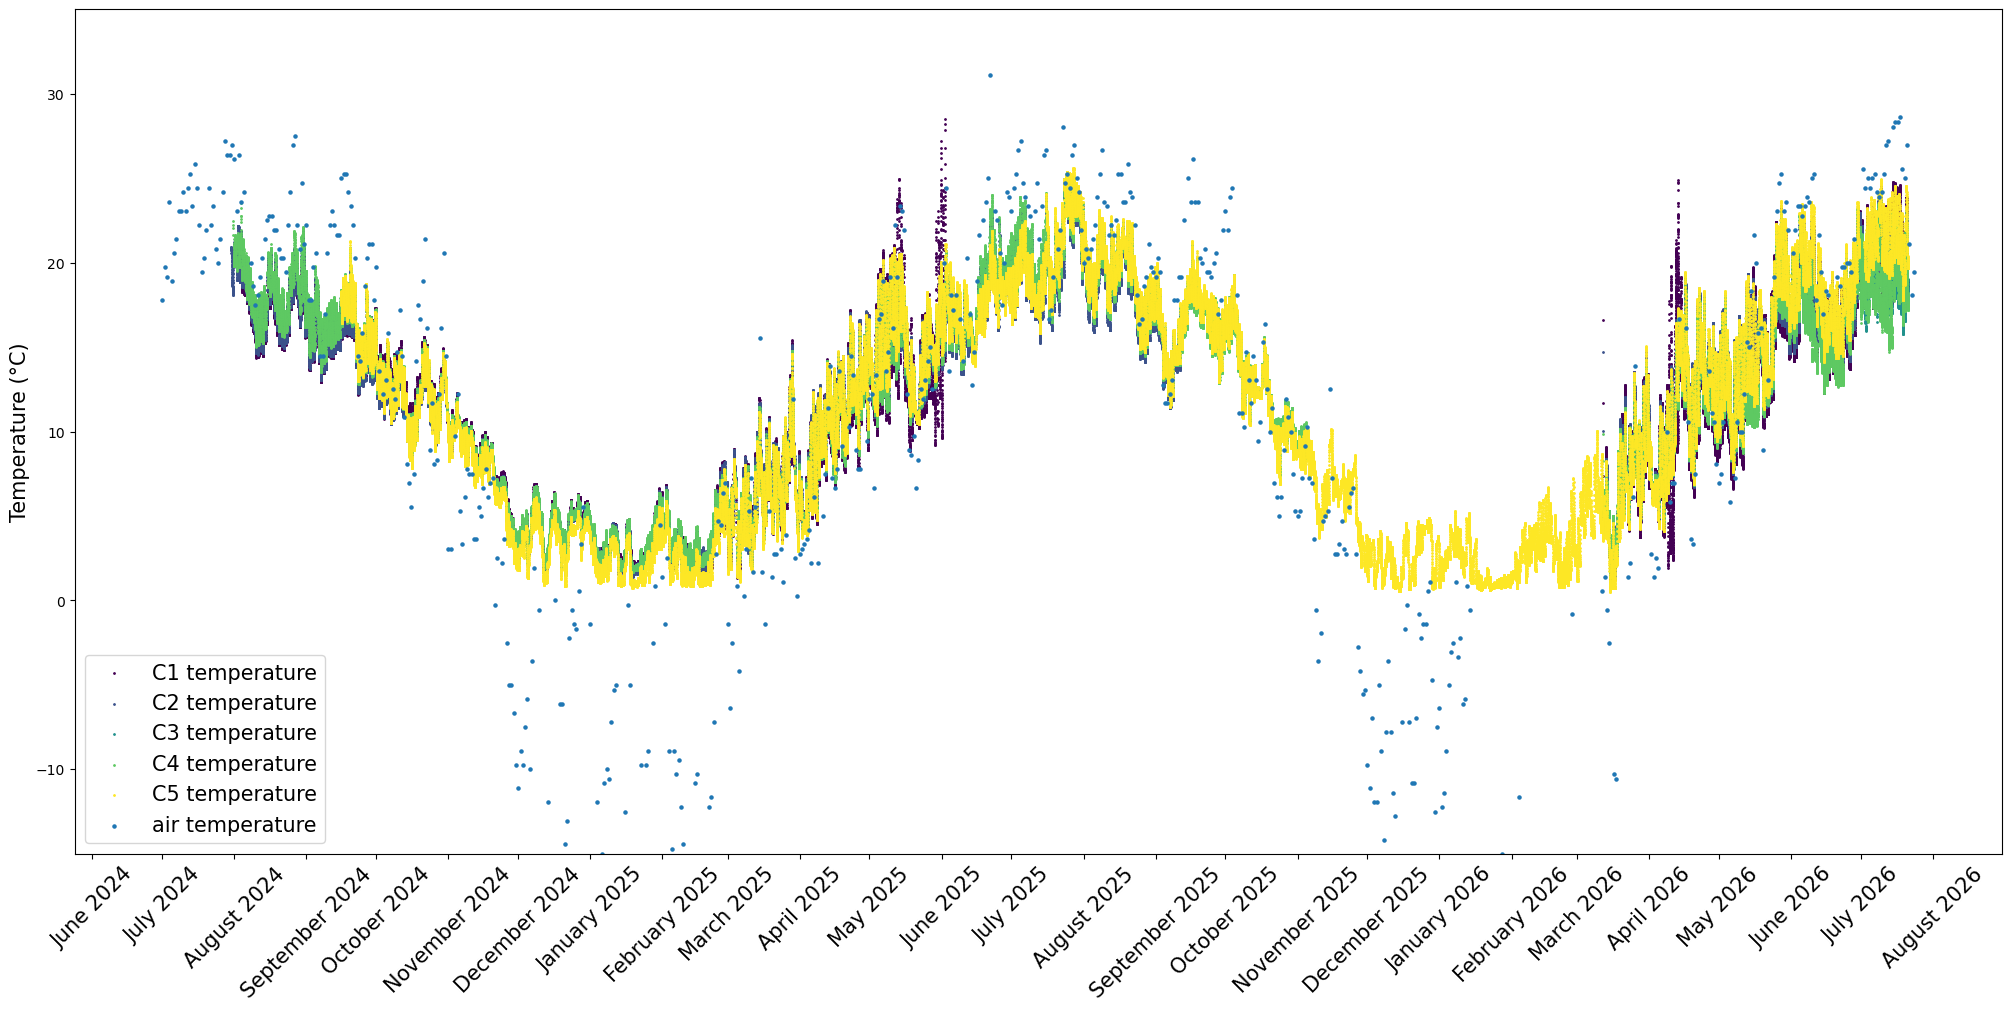

In [293]:
fig, ax = plt.subplots(layout='constrained', figsize=(20, 10))
ax.scatter(C1hobodf.index, C1hobodf.FilteredTemp, s = 1, color = one, label = 'C1 temperature')
ax.scatter(C2hobodf.index, C2hobodf.FilteredTemp, s = 1, color = two, label = 'C2 temperature')
ax.scatter(midst.index, midst.FilteredTemp, s = 1, color = three, label = 'C3 temperature')
ax.scatter(C4hobodf.index, C4hobodf.FilteredTemp, s = 1, color = four, label = 'C4 temperature')
ax.scatter(C5hobodf.index, C5hobodf.FilteredTemp, s = 1, color = five, label = 'C5 temperature')

ax.scatter(weatherdf.Date, weatherdf.MeanTempC, s = 5, label = 'air temperature') 

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
plt.xticks(rotation=45, fontsize = 15)

# plt.xlabel('date', fontsize = 15)
plt.ylabel('Temperature (°C)', fontsize = 15)
plt.ylim((-15, 35))
# plt.xlim((pd.to_datetime("2025-10"), pd.to_datetime("2026-06")))



#plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
ax.legend(loc="lower left", fontsize = 15)
# fig.legend(loc='outside upper right')
#ax.legend(handles = [hobo, temptb, tempbb, tempta, tempba], labels = ["HOBO continuous data", "field data at top before pumping", "field data at bottom before pumping", "field data at top after pumping", "field data at bottom after pumping"])

plt.show()

### Plotting SPC data:

#### Upgradient versus downgradient SPC (downgradient SPC is lower).

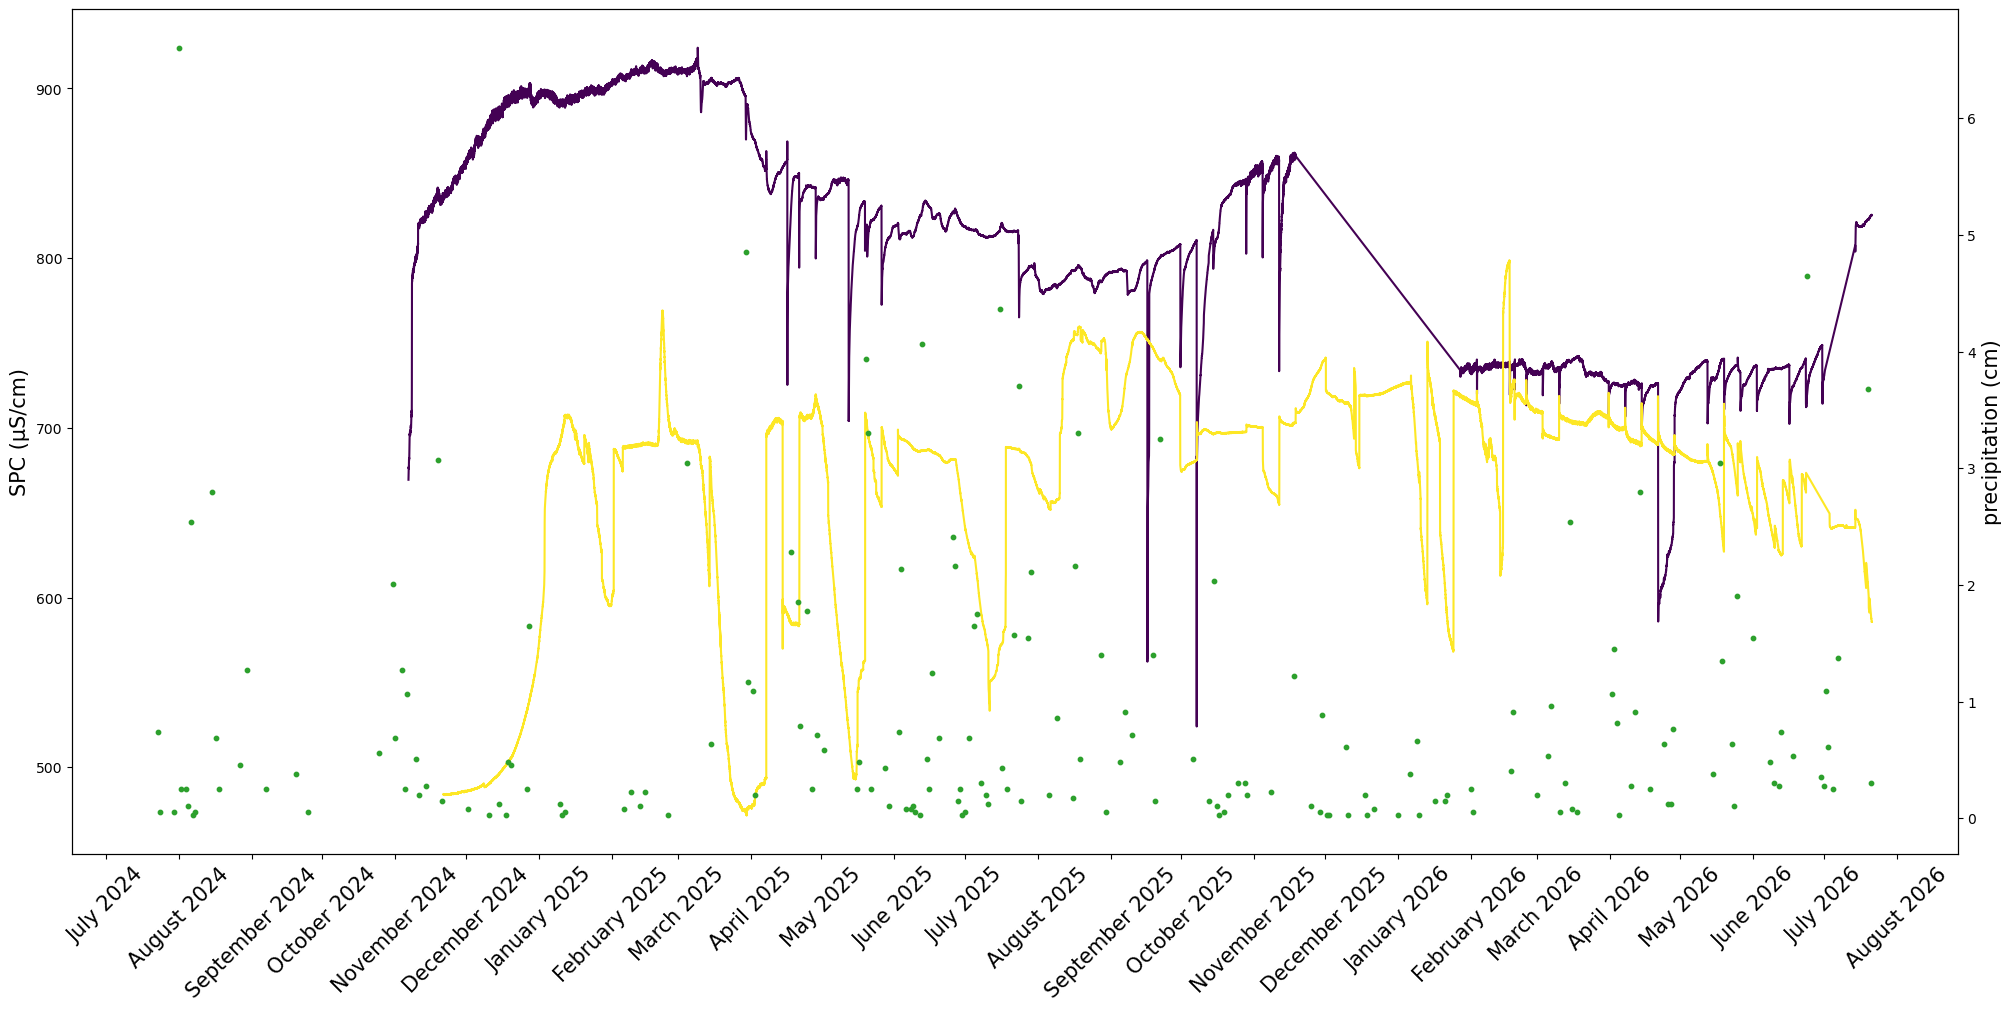

In [294]:
fig, ax1 = plt.subplots(layout='constrained', figsize=(20, 10))
# ax1.set_xlabel('time', fontsize=15)
ax1.set_ylabel('SPC (µS/cm)', fontsize=15)
P1 = ax1.plot(P1hobodf.index, P1hobodf.FilteredSPC, color=one, label = "downgradient SPC")
P5 = ax1.plot(P5hobodf.index, P5hobodf.FilteredSPC, color=five, label = "upgradient SPC")
ax1.tick_params(axis='x', rotation=45, labelsize=15)


ax2 = ax1.twinx() 
ax2.set_ylabel('precipitation (cm)', fontsize=15) 
# ax2.scatter(precip.Date, precip.PrecipitationCM, s = 0.2, color = "purple")
rain = ax2.scatter(precip.Date, precip.PrecipitationCM, s = 10, color = "tab:green", label = "daily average rainfall (cm)")
# ax2.plot((precip.Date, precip.PrecipitationCM))
# ax2.tick_params(axis='y', labelcolor=color)
# ax.twinx.plot(precip.Date, precip.PrecipitationCM, color = "bisque", alpha = 0.5, label = "precipitation (cm)")

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
# plt.xlabel("Year-Month")
# plt.ylabel("SPC (µS/cm)")
# plt.title("C1 and C5 conductivity")

# leg = P5 + P1 + rain
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-04-03"))

plt.show();

#### SPC in the stream versus the piezometer at one location (you can change the code in the cell above to show this graph with rainfall):

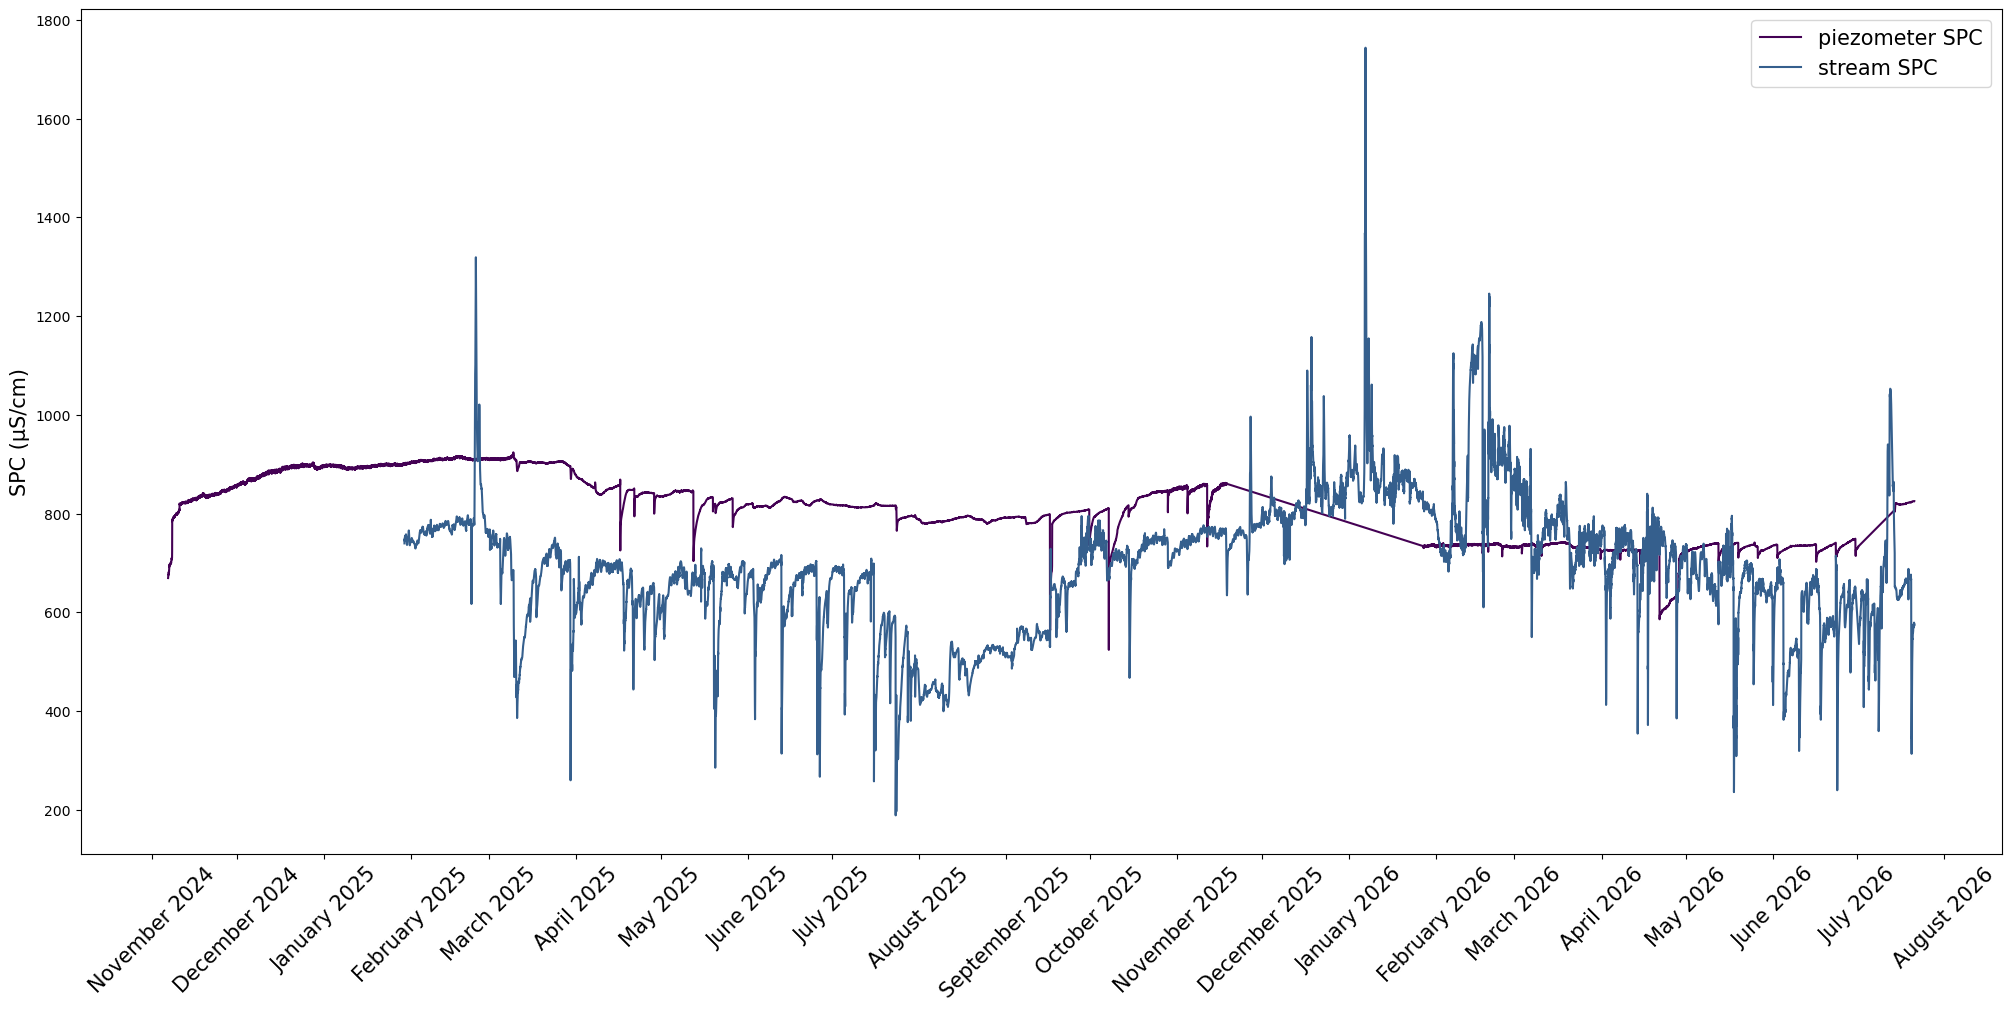

In [334]:
fig, ax = plt.subplots(layout='constrained', figsize=(20, 10))
ax.plot(P1hobodf.index, P1hobodf.FilteredSPC, color=one, label = "piezometer SPC")
ax.plot(downst.index, downst.FilteredSPC, color=viridis(0.3), label = "stream SPC")
ax.tick_params(axis='x', rotation=45, labelsize=15)

# Change to 
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
            # if you are zoomed out. DayLocator crowds the axis labels if you are looking at a period of more than a couple days.
# ax.xaxis.set_major_locator(mdates.DayLocator())
# ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %B %Y'))
# plt.xlabel('time')
plt.ylabel('SPC (µS/cm)', fontsize=15)
# plt.title("C1 and C5 conductivity")
plt.legend(fontsize=15)

# Zoom into a period of a few days. It often shows a much more stable SPC in the piezometer than in the creek.
# plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-04-03"))

plt.show()

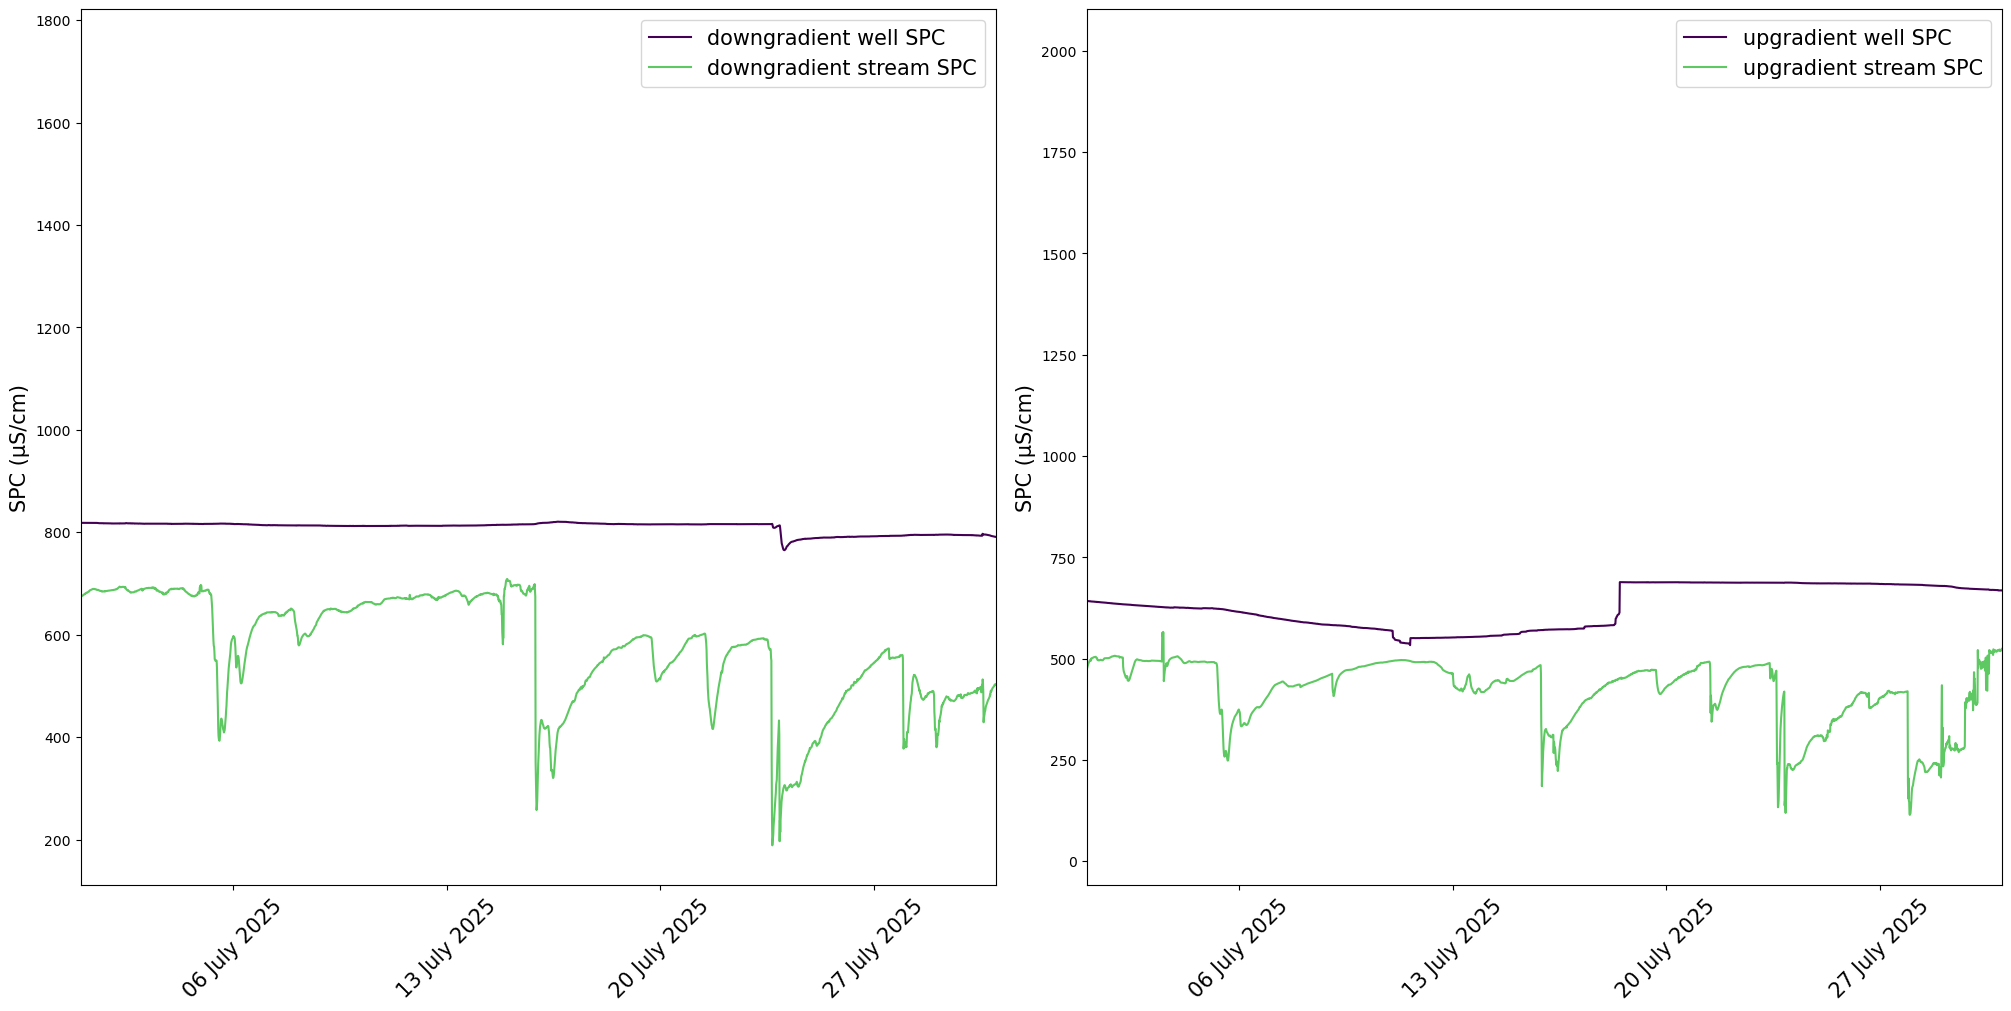

In [345]:
fig, (ax1, ax2) = plt.subplots(1, 2, layout='constrained', figsize=(20, 10))
ax1.plot(P1hobodf.index, P1hobodf.FilteredSPC, color=one, label = "downgradient well SPC")
ax1.plot(downst.index, downst.FilteredSPC, color=four, label = "downgradient stream SPC")
ax1.tick_params(axis='x', rotation=45, labelsize=15)

# Change to 
    # ax.xaxis.set_major_locator(mdates.MonthLocator())
    # ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
            # if you are zoomed out. DayLocator crowds the axis labels if you are looking at a period of more than a couple days.
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %B %Y'))

# plt.xlabel('time')
ax1.set_ylabel('SPC (µS/cm)', fontsize=15)
# plt.title("C1 and C5 conductivity")
ax1.legend(fontsize=15)

ax2.plot(P5hobodf.index, P5hobodf.FilteredSPC, color=one, label = "upgradient well SPC")
ax2.plot(C5hobodf.index, C5hobodf.FilteredSPC, color=four, label = "upgradient stream SPC")
ax2.tick_params(axis='x', rotation=45, labelsize=15)

# Change to 
    # ax.xaxis.set_major_locator(mdates.MonthLocator())
    # ax.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
            # if you are zoomed out. DayLocator crowds the axis labels if you are looking at a period of more than a couple days.
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %B %Y'))

# plt.xlabel('time')
ax2.set_ylabel('SPC (µS/cm)', fontsize=15)
# plt.title("C1 and C5 conductivity")
ax2.legend(fontsize=15)

# Zoom into a period of a few days. It often shows a much more stable SPC in the piezometer than in the creek.
ax1.set_xlim(pd.to_datetime("2025-07-01"), pd.to_datetime("2025-07-31"))
ax2.set_xlim(pd.to_datetime("2025-07-01"), pd.to_datetime("2025-07-31"))

plt.savefig('SPCFig.png', dpi=300, bbox_inches='tight')
plt.show()

## Resampling the data

Looking at daily mean can help smooth the curves and clean up trends between weather and SPC. You can resample any of the data sets to show the average daily SPC, temp, etc. Below are two examples--the first is a stacked figure showing the difference between regular filtered data and data resampled for daily average, and the second is a plot of SPC in the creek and piezometer at one station plotted against rainfall. Because the weather data shows only the total precipitaion for one day, we should look at it against one average SPC data point from each day (especially when looking at it on a day-to-day scale). 

In [313]:
# Resample the data.
P5davg = P5hobodf.resample('D').mean()
C5davg = C5hobodf.resample('D').mean()

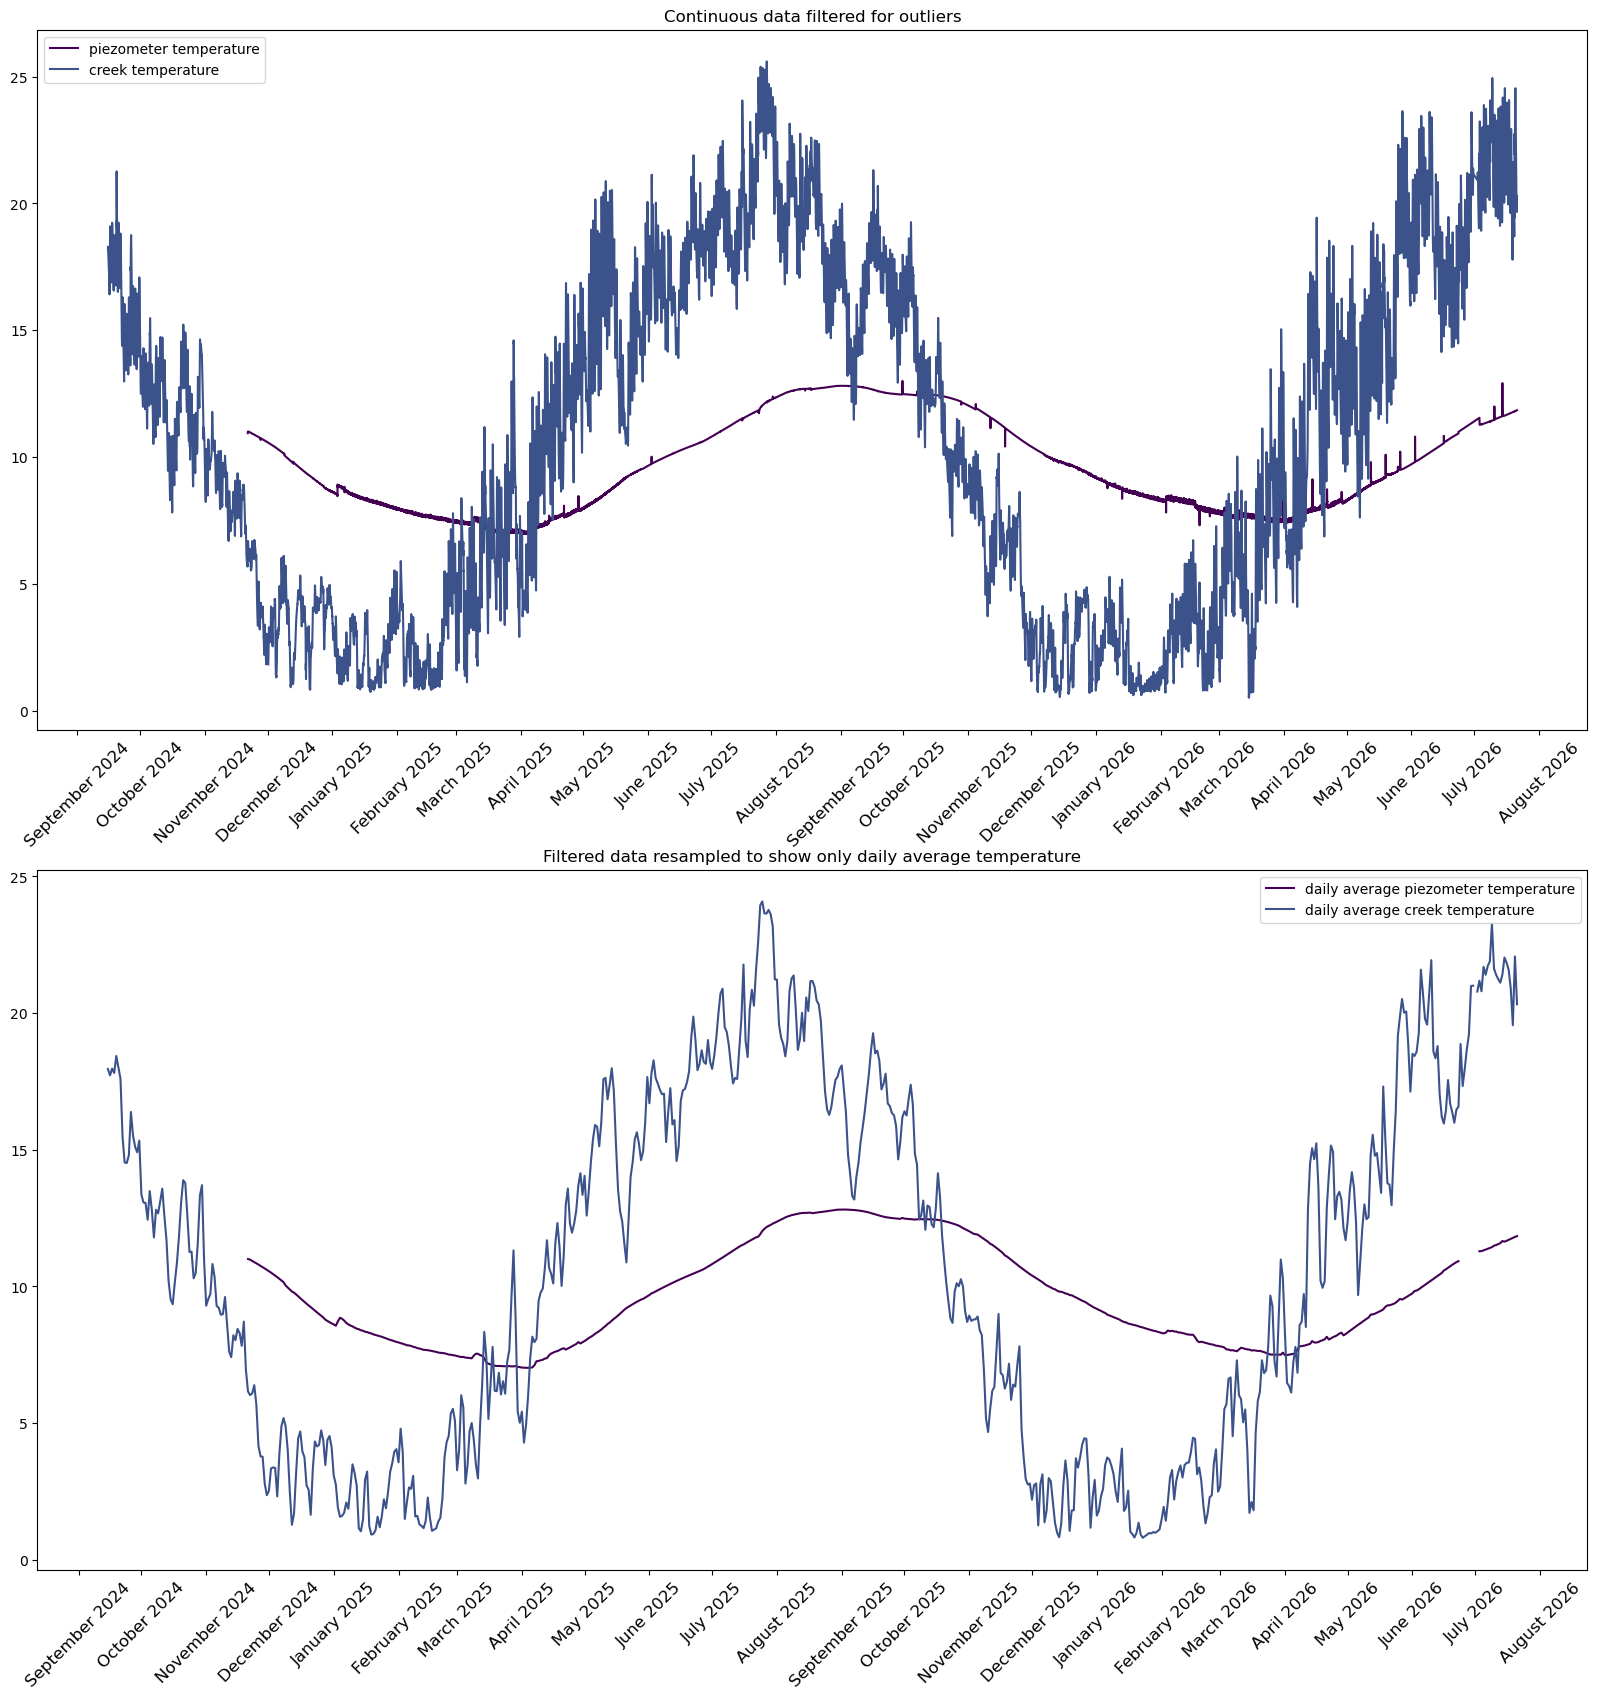

In [314]:
fig, (ax1, ax2) = plt.subplots(2, figsize = (20, 20))

ax1.plot(P5hobodf.index, P5hobodf.FilteredTemp, color=one, label = "piezometer temperature")
ax1.plot(C5hobodf.index, C5hobodf.FilteredTemp, color=two, label = "creek temperature")
ax1.set_title('Continuous data filtered for outliers')

ax2.plot(P5davg.index, P5davg.FilteredTemp, color=one, label = "daily average piezometer temperature")
ax2.plot(C5davg.index, C5davg.FilteredTemp, color=two, label = "daily average creek temperature")
ax2.set_title('Filtered data resampled to show only daily average temperature')

ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
ax1.tick_params(axis='x', rotation=45, labelsize=12)
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))
ax2.tick_params(axis='x', rotation=45, labelsize=12)

ax1.legend()
ax2.legend()
plt.show()

In [298]:
# Resample the piezometer data.
P1davg = P1hobodf.resample('D').mean()

In [299]:
# Resample the stream data.
downstdavg = downst.resample('D').mean()

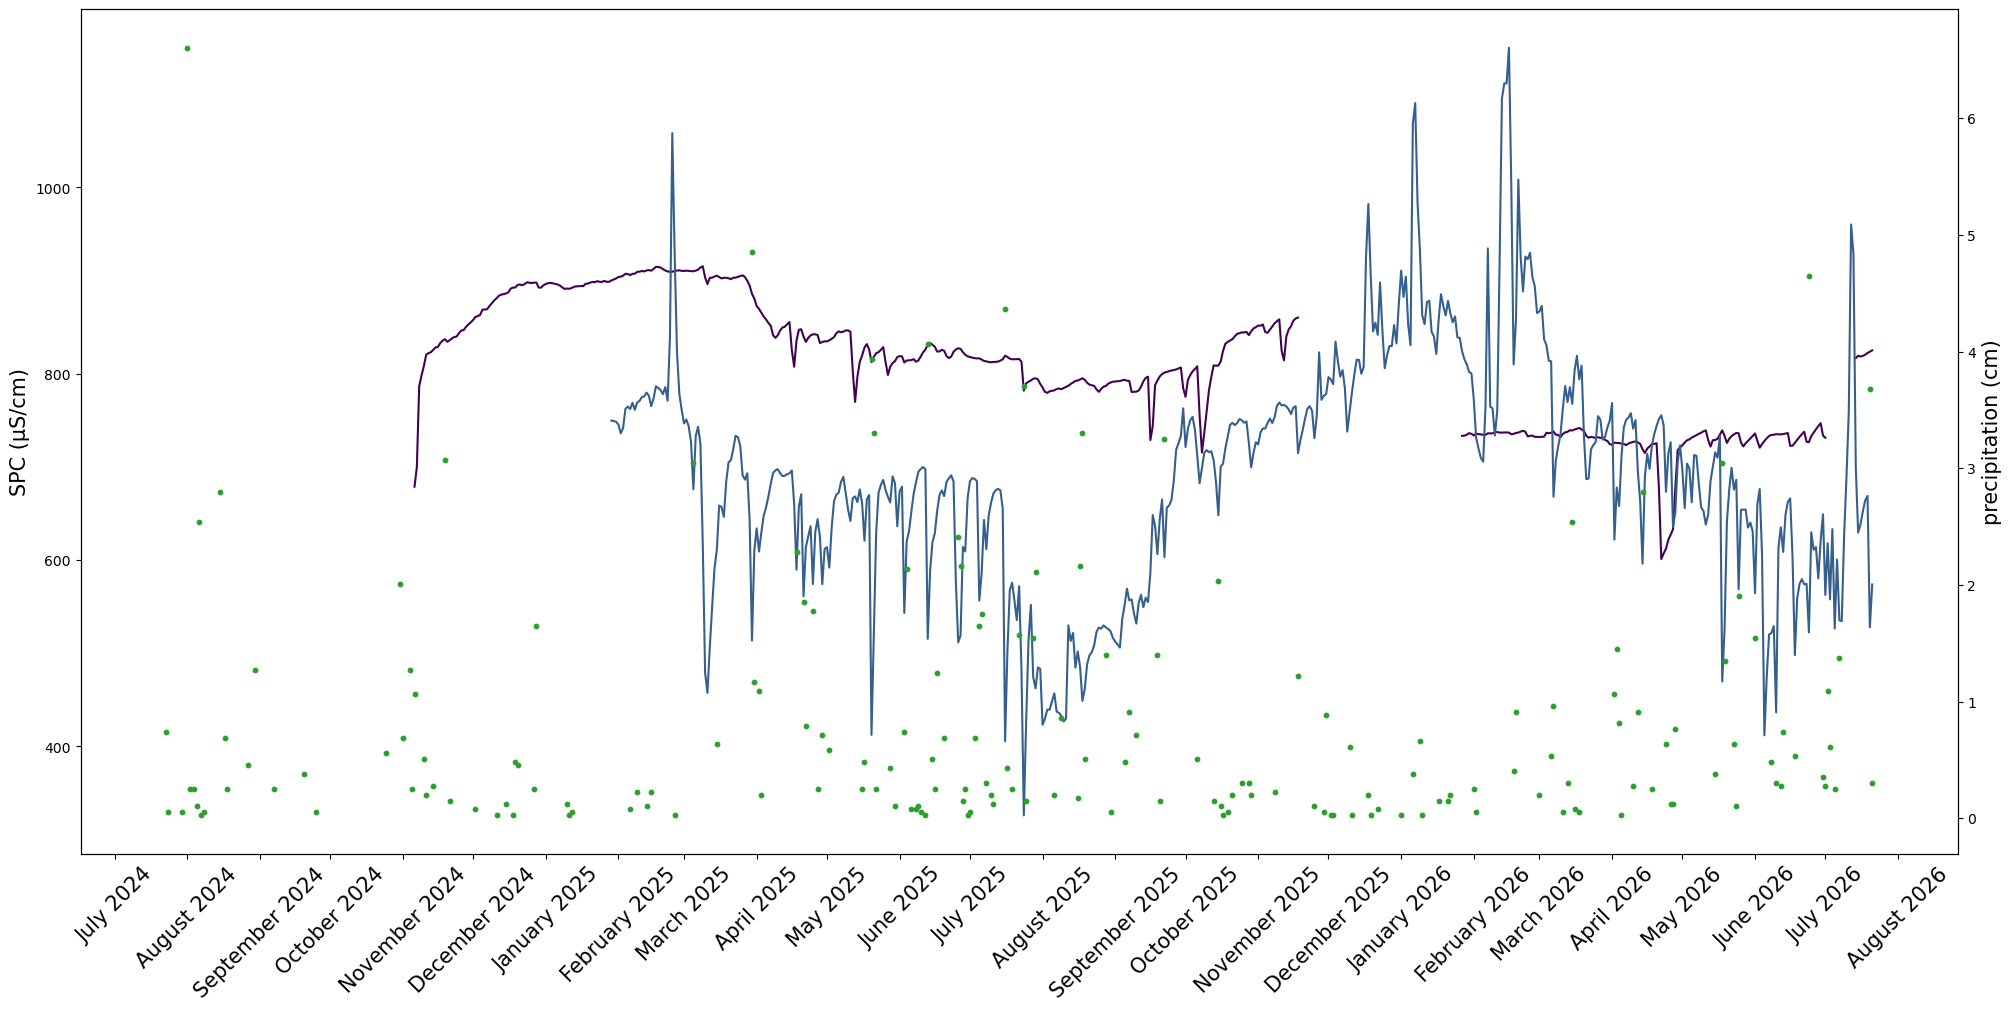

In [180]:
fig, ax1 = plt.subplots(layout='constrained', figsize=(20, 10))
# ax1.set_xlabel('time', fontsize=15)
ax1.set_ylabel('SPC (µS/cm)', fontsize=15)
P1 = ax1.plot(P1davg.index, P1davg.FilteredSPC, color=one, label = "P1 daily average SPC")
C1 = ax1.plot(downstdavg.index, downstdavg.FilteredSPC, color=viridis(0.3), label = "downstream creek daily average SPC")
ax1.tick_params(axis='x', rotation=45, labelsize=15)


ax2 = ax1.twinx() 
ax2.set_ylabel('precipitation (cm)', fontsize=15) 
rain = ax2.scatter(precip.Date, precip.PrecipitationCM, s = 10, color = "tab:green", label = "daily average rainfall (cm)")


ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%B %Y'))

# leg = C1 + P1 + rain
# labs = [l.get_label() for l in leg]
# ax1.legend(leg, labs)

# plt.xlim(pd.to_datetime("2025-04-01"), pd.to_datetime("2025-04-03"))

plt.show();

### Looking at spring channel temperature and SPC:

In [296]:
# Resample the data.
P3davg = P3hobodf.resample('D').mean()
midstdavg = midst.resample('D').mean()
springdavg = spring.resample('D').mean()

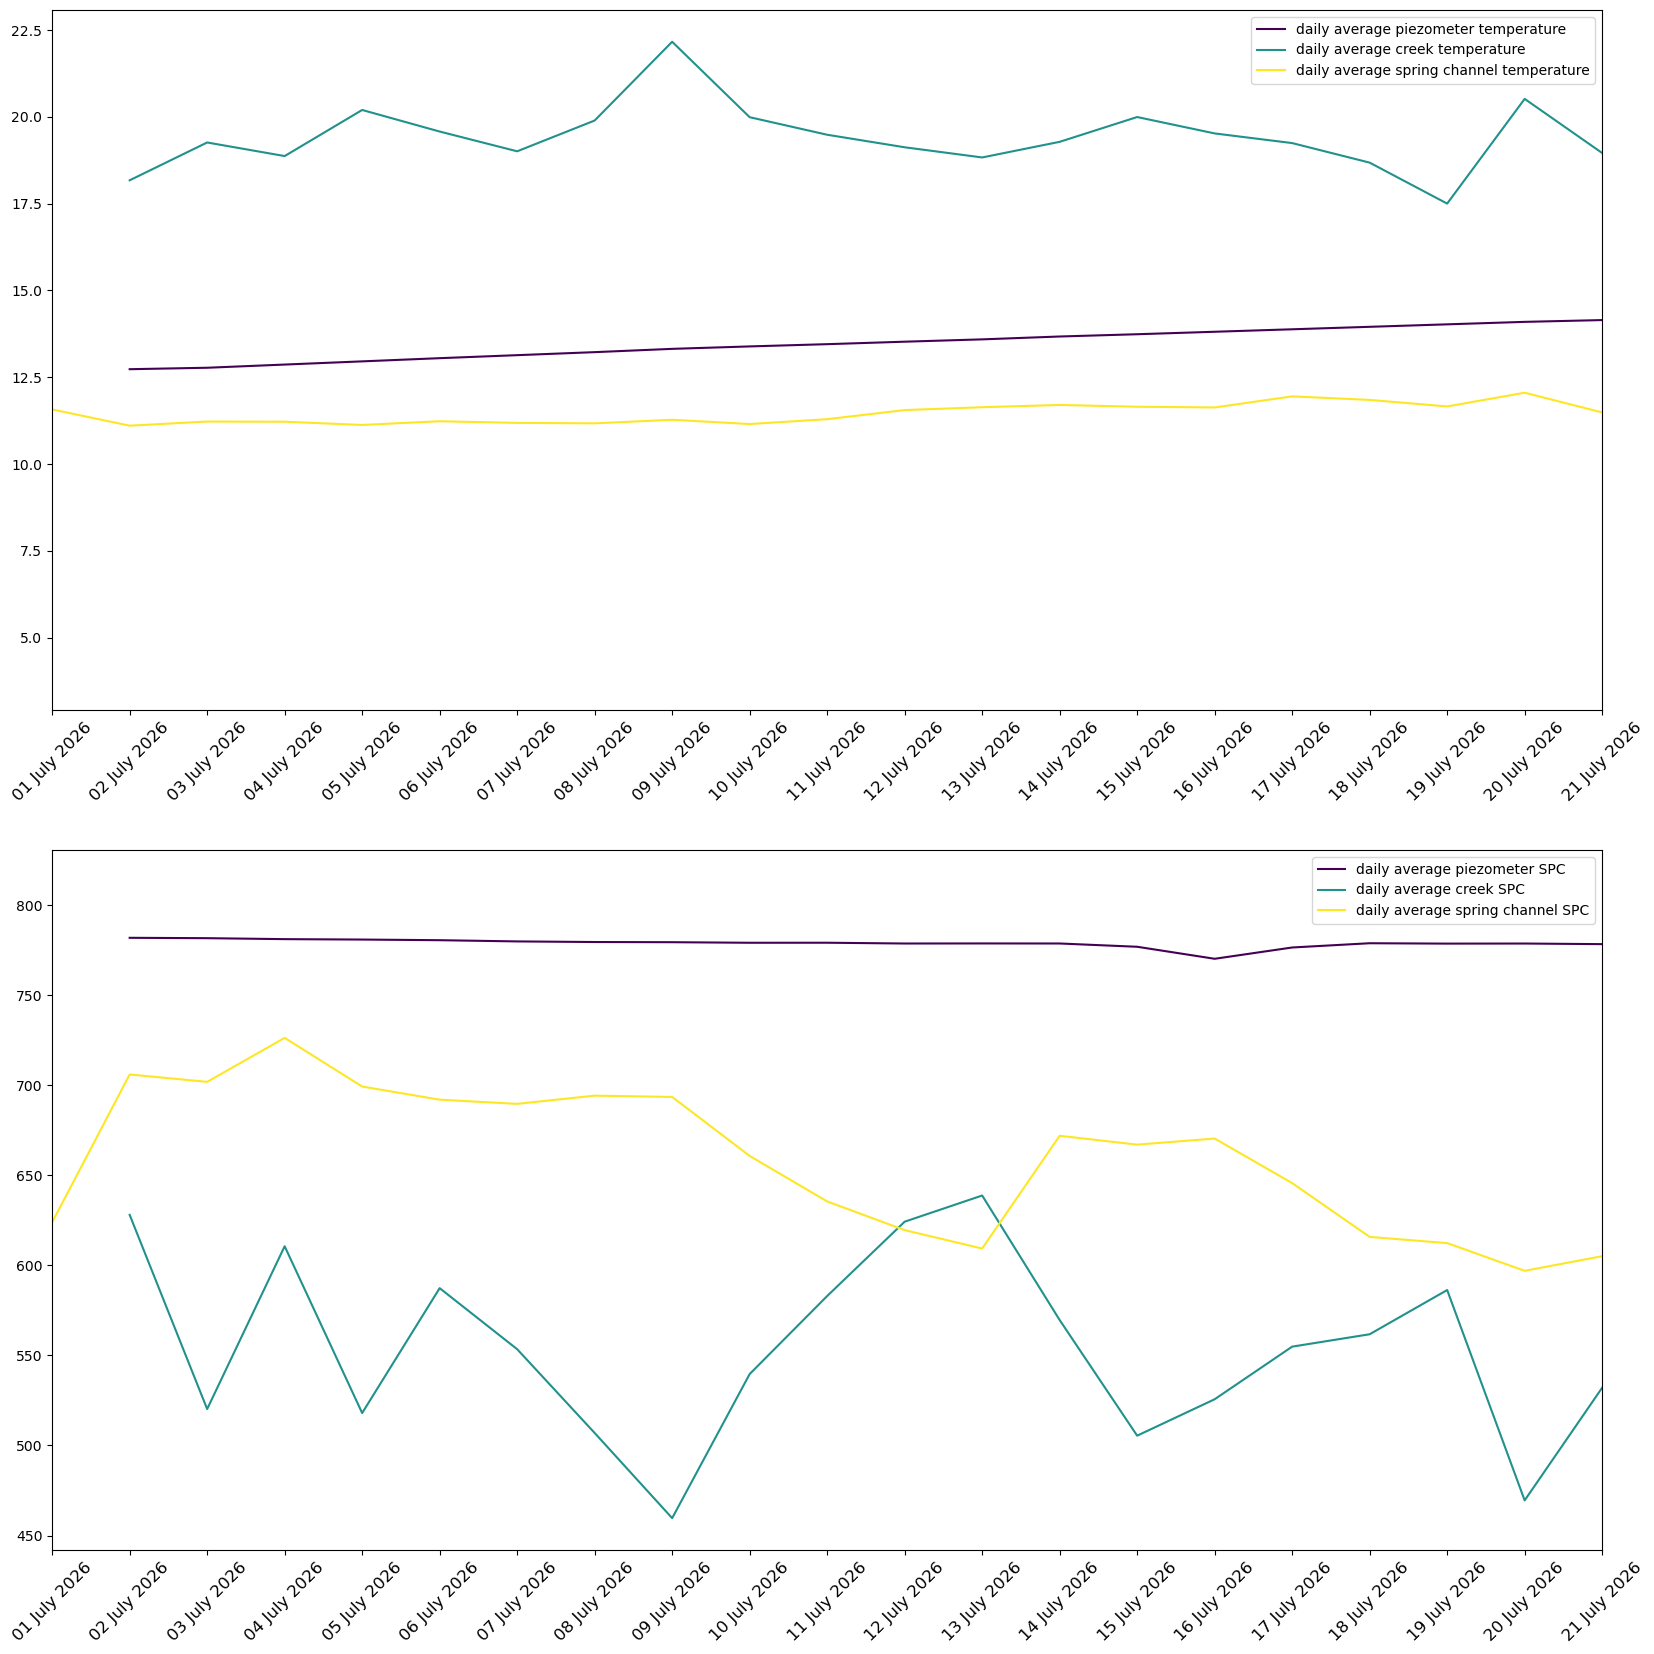

In [308]:
fig, (ax1, ax2) = plt.subplots(2, figsize = (20, 20))

ax1.plot(P3davg.index, P3davg.FilteredTemp, color=one, label = "daily average piezometer temperature")
ax1.plot(midstdavg.index, midstdavg.FilteredTemp, color=three, label = "daily average creek temperature")
ax1.plot(springdavg.index, springdavg.FilteredTemp, color=five, label = "daily average spring channel temperature")

ax2.plot(P3davg.index, P3davg.FilteredSPC, color=one, label = "daily average piezometer SPC")
ax2.plot(midstdavg.index, midstdavg.FilteredSPC, color=three, label = "daily average creek SPC")
ax2.plot(springdavg.index, springdavg.FilteredSPC, color=five, label = "daily average spring channel SPC")

ax1.set_xlim(pd.to_datetime('2026-07-01'), pd.to_datetime('2026-07-21'))
ax2.set_xlim(pd.to_datetime('2026-07-01'), pd.to_datetime('2026-07-21'))

ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %B %Y'))
ax1.tick_params(axis='x', rotation=45, labelsize=12)
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %B %Y'))
ax2.tick_params(axis='x', rotation=45, labelsize=12)

ax1.legend()
ax2.legend()
plt.show()

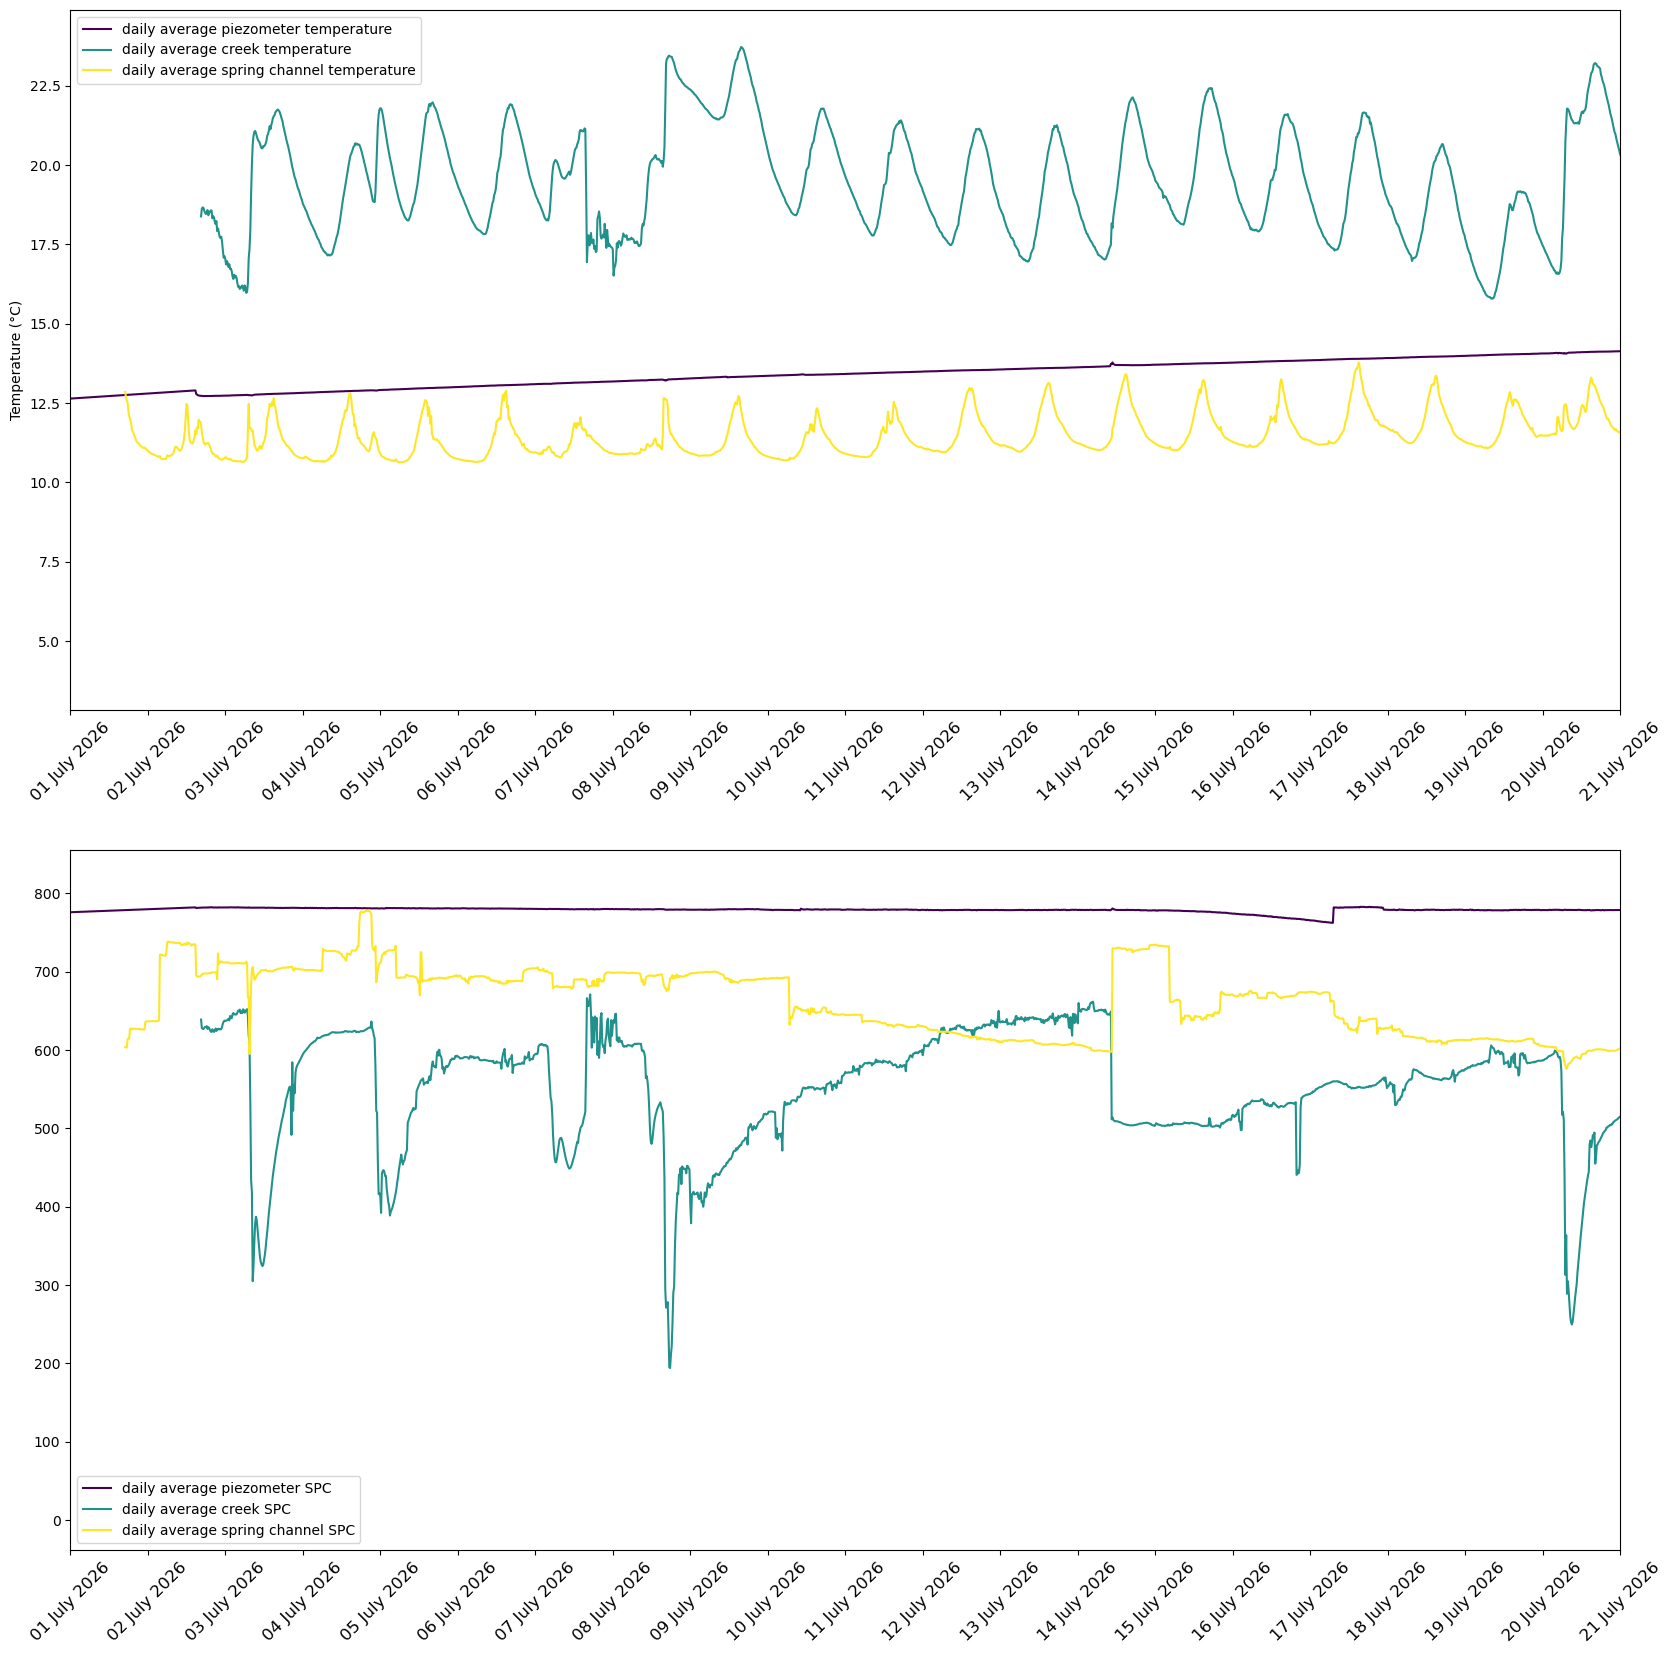

In [328]:
fig, (ax1, ax2) = plt.subplots(2, figsize = (20, 20))

ax1.plot(P3hobodf.index, P3hobodf.FilteredTemp, color=one, label = "daily average piezometer temperature")
ax1.plot(midst.index, midst.FilteredTemp, color=three, label = "daily average creek temperature")
ax1.plot(spring.index, spring.FilteredTemp, color=five, label = "daily average spring channel temperature")
ax1.set_ylabel('Temperature (°C)')

ax2.plot(P3hobodf.index, P3hobodf.FilteredSPC, color=one, label = "daily average piezometer SPC")
ax2.plot(midst.index, midst.FilteredSPC, color=three, label = "daily average creek SPC")
ax2.plot(spring.index, spring.FilteredSPC, color=five, label = "daily average spring channel SPC")

ax1.set_xlim(pd.to_datetime('2026-07-01'), pd.to_datetime('2026-07-21'))
ax2.set_xlim(pd.to_datetime('2026-07-01'), pd.to_datetime('2026-07-21'))

ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %B %Y'))
ax1.tick_params(axis='x', rotation=45, labelsize=12)
ax2.xaxis.set_major_locator(mdates.DayLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %B %Y'))
ax2.tick_params(axis='x', rotation=45, labelsize=12)

ax1.legend()
ax2.legend()

plt.savefig('SpringChannelFig.png', dpi=300, bbox_inches='tight')
plt.show()

Cleaning the data further: Because the Hobos take measurements on offset 15-min intervals, it can be helpful to reassign the timestamps to the nearest 15 minutes. 

In [140]:
# Resample the piezometer data.
P1hobodf.set_index('Date-Time', inplace=True)
P1hobodf.index = P1hobodf.index.round('15min')

In [141]:
# Resample the stream data.
downst.set_index('Date-Time', inplace=True)
downst.index = downst.index.round('15min')

In [144]:
# For ease, I just delete the four rows that correspond to the second 1 am hour on November 2. 
P1hobodf = P1hobodf.loc[~P1hobodf.index.duplicated(keep='first')]

In [145]:
# Check the creek data for the same error. If it exists, run .index.duplicated(keep='first') to remove it.
downst = downst.loc[~downst.index.duplicated(keep='first')]